# 📌 목차
1. 문제 정의 및 데이터 이해
2. 데이터 전처리
3. 탐색적 데이터 분석 (EDA)
   - 3.1 단변량 분석
   - 3.2 이변량 분석
4. 모델링
5. 모델 평가
6. 모델 해석
7. 결론 및 비즈니스 인사이트

---


In [2]:
import pandas as pd

df = pd.read_csv('churn-bigml-80.csv')
df_test = pd.read_csv('churn-bigml-20.csv')

# 1. 문제 정의 및 데이터 이해

---

## 목표 설정

- **비즈니스 문제**  
  통신사는 고객 이탈(Churn)로 인해 지속적인 매출 손실을 겪고 있다.  
  신규 고객 확보 비용은 기존 고객 유지 비용보다 높기 때문에,  
  이탈 가능성이 높은 고객을 사전에 식별하여 선제적인 대응하는 것이 중요하다.  
  본 분석은 이러한 문제의식에서 출발하여,  
  고객의 이용 패턴 데이터를 기반으로 이탈에 영향을 미치는 주요 요인을 파악하고  
  이를 활용해 고객 이탈 여부를 예측하는 모델을 구축하는 것을 목표로 한다.  

- **분석 목표**  
  본 분석의 목적은 다음 두 가지에 있다.

  - 고객 이탈에 영향을 미치는 핵심 요인을 데이터 기반으로 도출

  - 단순한 예측 정확도보다,
  이탈을 설명할 수 있고 비즈니스적으로 개입 가능한 변수를 중심으로 해석

- **성공 지표**  
 모델 성능 평가는 다음 지표를 중심으로 수행한다.

  - Accuracy

  - Precision

  - Recall

  - F1-score

  - ROC-AUC

특히 본 문제에서는
**이탈 고객을 놓치는 경우(False Negative)**가
비즈니스 손실로 직결되므로,

➡️ Recall과 ROC-AUC를 중요한 판단 기준으로 삼는다.

## 데이터셋 구조 파악

본 분석에서는 통신사 고객 이탈 데이터를 사용하였다.

- `churn-bigml-80.csv` : 모델 학습 및 검증용 데이터  
- `churn-bigml-20.csv` : 최종 테스트용 데이터  


훈련 데이터 기준으로 데이터의 크기와 구조를 확인한 결과,

- 총 2,666명의 고객 데이터

- 20개의 변수로 구성되어 있다.

In [3]:
df.shape


(2666, 20)

데이터 타입 및 결측치 여부를 확인한 결과,

- 모든 컬럼에 결측치는 존재하지 않는다.

- 데이터 타입은 다음과 같이 구성되어 있다.


  - 수치형 변수(int64, float64)
  - 범주형 변수(object)
  - 타깃 변수(Churn, bool)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

또한 타깃 변수인 Churn의 분포를 확인한 결과,

  - 이탈 고객(True): 약 14.6%
  - 유지 고객(False): 약 85.4%

이탈 고객 비율이 상대적으로 낮은 불균형 데이터임을 확인할 수 있다.  
이는 이후 모델링 단계에서 클래스 불균형을 고려한 접근이 필요함을 시사한다.

In [5]:
df['Churn'].value_counts(normalize=True)


Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

# 변수 의미 및 비즈니스 맥락 이해

본 데이터셋은 고객의 통화 사용 패턴, 요금제 이용 여부, 고객센터 이용 이력 등  
고객의 서비스 이용 행태를 정량적으로 나타내는 변수들로 구성되어 있다.

각 변수의 의미는 다음과 같다.

각 변수의 의미와 비즈니스 맥락 이해

| 컬럼명                        | 의미                        | 
| -------------------------- | ------------------------- | 
| **State**                  | 고객이 거주하는 주(State)         |
| **Account length**         | 고객 계정 유지 기간(일)            | 
| **Area code**              | 지역 전화 코드                  | 
| **International plan**     | 국제전화 요금제 사용 여부 (Yes/No)   | 
| **Voice mail plan**        | 음성 사서함 요금제 사용 여부 (Yes/No) | 
| **Number vmail messages**  | 음성 사서함 메시지 수              | 
| **Total day minutes**      | 주간 통화 총 시간(분)             | 
| **Total day calls**        | 주간 통화 횟수                  | 
| **Total day charge**       | 주간 통화 요금                  | 
| **Total eve minutes**      | 저녁 통화 총 시간(분)             | 
| **Total eve calls**        | 저녁 통화 횟수                  | 
| **Total eve charge**       | 저녁 통화 요금                  | 
| **Total night minutes**    | 야간 통화 총 시간(분)             | 
| **Total night calls**      | 야간 통화 횟수                  | 
| **Total night charge**     | 야간 통화 요금                  | 
| **Total intl minutes**     | 국제 통화 총 시간(분)             | 
| **Total intl calls**       | 국제 통화 횟수                  | 
| **Total intl charge**      | 국제 통화 요금                  |
| **Customer service calls** | 고객센터 문의 횟수                | 
| **Churn**                  | 고객 이탈 여부 (True/False)     | 


이러한 변수들은 이후 탐색적 데이터 분석(EDA) 단계에서
고객 이탈과의 관계를 분석하고, 모델 학습에 활용될 주요 설명 변수로 사용된다.

# 2.데이터 전처리

본 단계에서는 탐색적 데이터 분석(EDA) 및 모델 학습을 위해  
데이터의 품질을 점검하고, 불필요하거나 왜곡을 유발할 수 있는 전처리를 최소화하는 것을 목표로 하였다.  
즉, 데이터 자체가 가진 고객 행동 정보를 최대한 보존하는 방향으로 전처리를 수행하였다.


# 2.1 결측치 처리

In [6]:
df.isnull().sum()


State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

결측치 확인 결과, 모든 변수에서 결측치가 발견되지 않았다.

이에 따라 결측치 대체(평균/중앙값)나 삭제와 같은 추가적인 처리는 수행하지 않았다.  
결측치가 없는 데이터에 불필요한 전처리를 적용할 경우,  
오히려 데이터 분포를 왜곡할 수 있다고 판단하였다.


## 2.2 이상치 탐지 및 처리

수치형 변수에 대해 이상치 존재 여부를 확인하기 위해
기초 통계량(describe) 및 IQR 기반 탐지를 수행하였다.

In [7]:
df.describe()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


수치형 변수에 대해 기초 통계량(describe)을 확인하고,  
IQR 기준으로 극단값 존재 여부를 점검하였다.

일부 변수에서 상대적으로 큰 값이 관찰되었으나,  
해당 변수들은 통화 시간, 통화 요금, 통화 횟수 등  
고객의 실제 서비스 이용 강도를 직접적으로 반영하는 지표로 판단하였다.

따라서 본 분석에서는 이러한 값들을 오류(outlier)로 간주하지 않고,  
고객 행동의 특성을 보존하기 위해 모든 값을 유지하였다.


## 2.3 데이터 타입 확인 및 변수 정리

In [8]:
df.dtypes


State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

데이터 타입 확인 결과, 변수는 다음과 같이 구성되어 있다.

- 수치형 변수: 통화 시간, 통화요금, 통화 횟수 등

- 범주형 변수: International plan, Voice mail plan

- 타깃 변수: Churn (bool)

범주형 변수 중 State는 범주 수가 많아  
원-핫 인코딩 시 차원 증가 문제가 발생할 수 있으며,  
이탈과의 직접적인 비즈니스 가설을 설정하기 어렵다고 판단하였다.

따라서 본 분석에서는 State 변수를 제거하였다.

In [9]:
df = df.drop(columns=['State'])


International plan, Voice mail plan 변수의 인코딩은
모델 학습 단계에서 수행할 예정이다.

이와 같은 전처리 과정을 통해  
데이터의 품질은 유지하면서도,  
모델 해석과 비즈니스 인사이트 도출에 집중할 수 있는 데이터셋을 구성하였다.


## 3. EDA

본 장에서는 고객 이탈(Churn)에 영향을 미칠 가능성이 있는 변수들의 분포와 특성을 탐색적으로 분석하였다.  
단변량 분석을 통해 각 변수의 기본적인 분포를 확인하고,  
   이후 이변량 분석을 통해 이탈 여부에 따른 차이를 살펴본다.

# 3.1 단변량 분석 (Univariate Analysis)

(1) 수치형 변수 분포 확인

수치형 변수에 대해 히스토그램을 통해 전체적인 분포 형태를 확인하였다.


array([[<Axes: title={'center': 'Account length'}>,
        <Axes: title={'center': 'Area code'}>,
        <Axes: title={'center': 'Number vmail messages'}>,
        <Axes: title={'center': 'Total day minutes'}>],
       [<Axes: title={'center': 'Total day calls'}>,
        <Axes: title={'center': 'Total day charge'}>,
        <Axes: title={'center': 'Total eve minutes'}>,
        <Axes: title={'center': 'Total eve calls'}>],
       [<Axes: title={'center': 'Total eve charge'}>,
        <Axes: title={'center': 'Total night minutes'}>,
        <Axes: title={'center': 'Total night calls'}>,
        <Axes: title={'center': 'Total night charge'}>],
       [<Axes: title={'center': 'Total intl minutes'}>,
        <Axes: title={'center': 'Total intl calls'}>,
        <Axes: title={'center': 'Total intl charge'}>,
        <Axes: title={'center': 'Customer service calls'}>]], dtype=object)

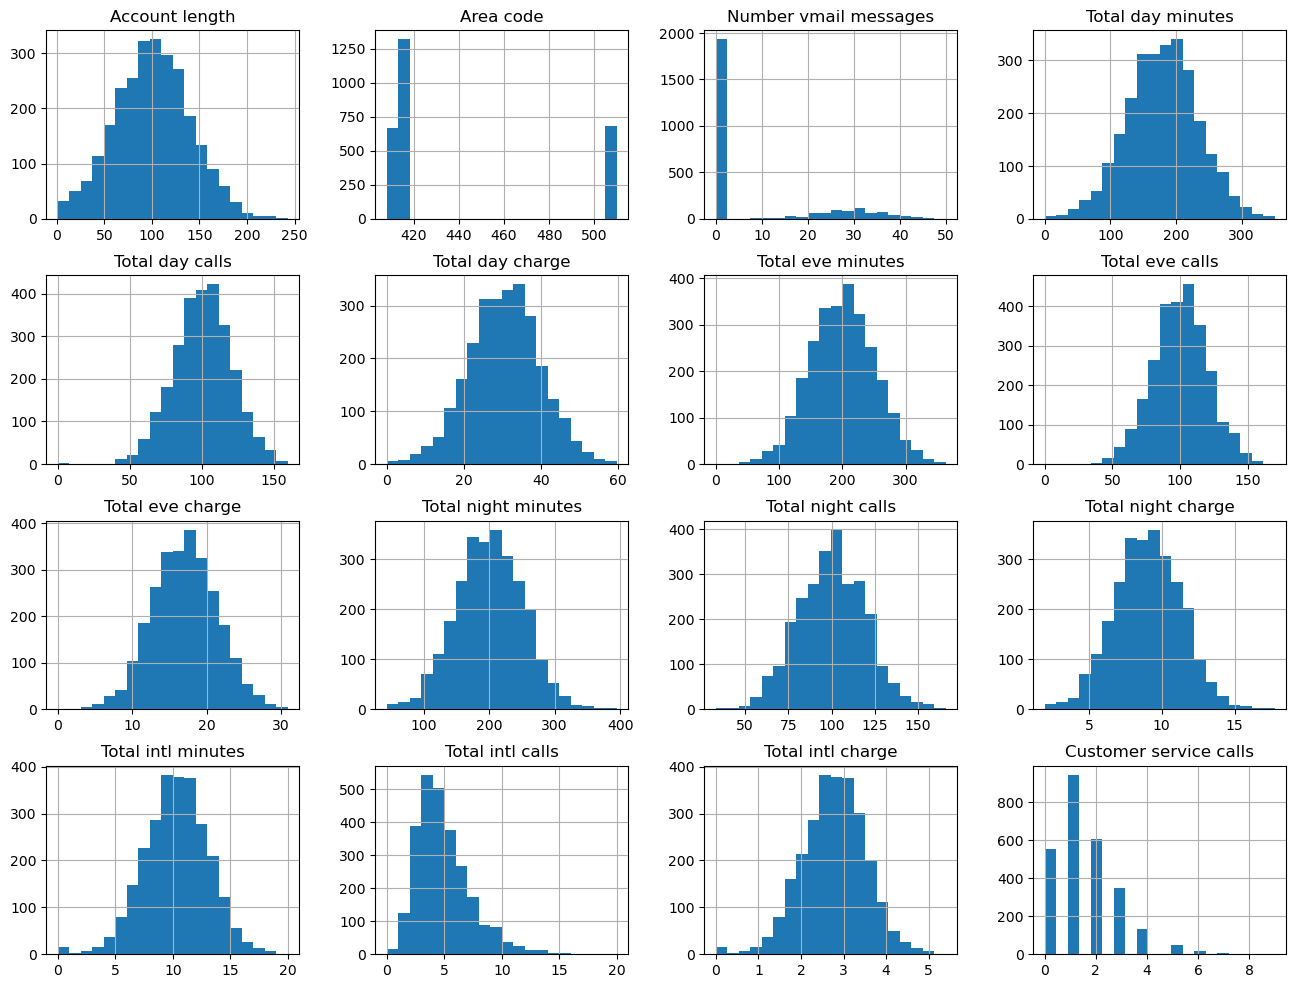

In [10]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols].hist(figsize=(16, 12), bins=20)


- 통화 시간, 통화 요금, 통화 횟수 관련 변수들은 전반적으로 정규분포에 가까운 형태를 보였다.

- 이는 고객들의 서비스 사용량이 특정 평균값을 중심으로 자연스럽게 분포하고 있음을 의미한다.

- 일부 변수에서는 오른쪽 꼬리가 긴 분포(right-skewed) 가 관찰되었는데,
  - 이는 소수의 고사용량(헤비 유저) 고객이 존재함을 시사한다.


## (2) 기초 통계량 확인

수치형 변수의 평균, 중앙값, 표준편차, 사분위수를 확인하였다.

In [11]:
df[numeric_cols].describe()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


- 변수 간 스케일 차이가 상당히 존재함을 확인하였다.

- 예를 들어 통화 횟수와 통화 요금은 값의 범위가 크게 다르다.

- 이는 이후 모델 학습 단계에서 스케일링이 필요함을 시사한다.

## (3) 범주형 변수 빈도 확인

EDA 단계에서는 범주형 변수를 인코딩하지 않고,
각 변수의 분포를 그대로 확인하였다.

In [12]:
cat_cols = ['International plan', 'Voice mail plan']
for col in cat_cols:
    print(df[col].value_counts())


International plan
No     2396
Yes     270
Name: count, dtype: int64
Voice mail plan
No     1933
Yes     733
Name: count, dtype: int64


확인 결과,

- 국제전화 요금제(International plan)는 미사용 고객 비율이 높았으며

- 음성 사서함 요금제(Voice mail plan)는 사용/미사용 고객이 비교적 고르게 분포하였다.

이는 국제전화 요금제가 특정 고객군의 특성을 강하게 반영하는 반면,  
음성 사서함 요금제는 보다 일반적인 서비스 선택 요소일 가능성을 시사한다.”

## (4) 타깃 변수(Churn) 분포 확인

In [13]:
df['Churn'].value_counts(normalize=True)


Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64

- 이탈 고객 비율이 상대적으로 낮은 불균형 데이터(Imbalanced Data) 임을 확인하였다.

- 따라서 이후 모델 평가 시 Accuracy만으로 판단하는 것은 부적절하며,  
  Recall, Precision, F1-score, ROC-AUC 등의 지표를 함께 고려해야 한다.

## 3.2 이변량 분석 (Bivariate Analysis)
(1) 수치형 변수 vs Churn: 박스플롯으로 그룹 간 차이 확인

대표 변수 3개만 빠르게 확인 (고객센터/국제통화/주간통화시간)

본 단계에서는 이탈 여부(Churn)에 따라 주요 수치형 변수의 분포 차이를 확인하기 위해  
박스플롯(Boxplot)을 활용하여 두 그룹(True / False)을 비교하였다.

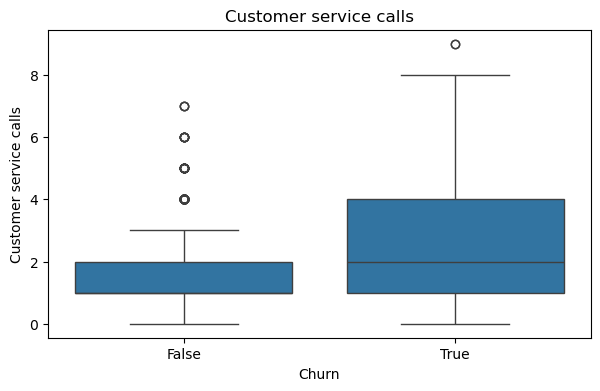

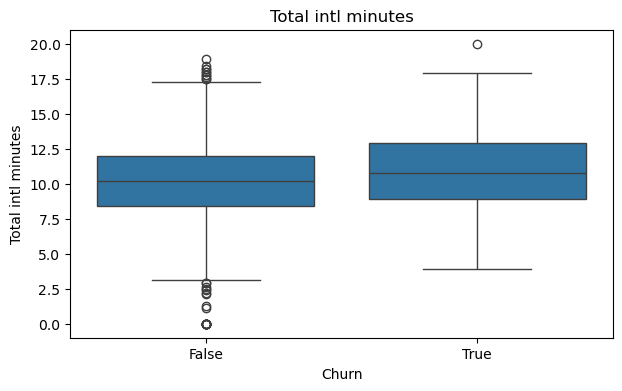

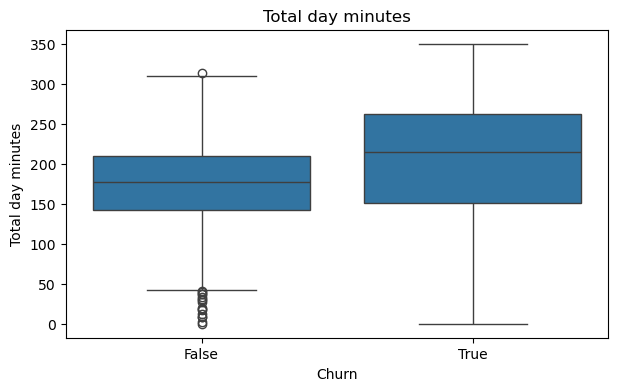

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

key_num = ['Customer service calls', 'Total intl minutes', 'Total day minutes']

for col in key_num:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x='Churn', y=col)
    plt.title(col)
    plt.show()


(1) Customer service calls

- 이탈 고객(True)의 중앙값이 유지 고객(False)보다 높음

- 이탈 고객 그룹에서 분산과 상단 이상치가 더 많이 관찰됨

- 유지 고객은 대부분 0~2회 문의에 집중됨

고객센터 문의 횟수는 이탈 여부에 따라 가장 뚜렷한 분포 차이를 보이는 변수이다.
잦은 문의는 서비스 불만 누적 가능성을 시사하며,
이탈을 예측하는 데 있어 핵심적인 설명 변수로 작용할 가능성이 높다.

(2) Total intl minutes

- 이탈 고객의 중앙값이 유지 고객보다 소폭 높음

- 두 그룹의 분포가 상당 부분 겹쳐 있음

- 극단적인 차이는 관찰되지 않음

국제 통화 사용량은 이탈 고객에서 다소 높은 경향을 보이나,  
단독 변수로서 이탈을 명확히 구분하기에는 한계가 있다.  
다른 변수들과 함께 결합될 때 보조적인 설명력을 가질 것으로 판단된다.

(3) Total day minutes

- 이탈 고객의 중앙값과 상위 구간이 유지 고객보다 높게 분포

- 고사용량 구간에서 이탈 고객 비중이 상대적으로 큼


주간 통화 사용량은 이탈 고객에서 전반적으로 더 높은 분포를 보였다.  
이는 고사용 고객일수록 서비스 품질에 대한 기대치가 높아  
불만 발생 시 이탈로 이어질 가능성이 크다는 점을 시사한다.

## (2) 범주형 변수 vs Churn: 교차표(Crosstab)로 이탈률 비교

In [15]:
for c in cat_cols:
    print(f"\n[Crosstab: {c} vs Churn] (row normalize)")
    print(pd.crosstab(df[c], df['Churn'], normalize='index'))



[Crosstab: International plan vs Churn] (row normalize)
Churn                  False     True 
International plan                    
No                  0.887312  0.112688
Yes                 0.562963  0.437037

[Crosstab: Voice mail plan vs Churn] (row normalize)
Churn               False     True 
Voice mail plan                    
No               0.832902  0.167098
Yes              0.911323  0.088677


- 국제전화 요금제를 쓰지 않는 고객은 이탈률이 약 11%
- 국제전화 요금제를 쓰는 고객은 이탈률이 무려 43.7%
  - 국제전화 요금제 사용 여부는 이탈과 매우 강한 연관성을 가진다.


- 음성 사서함 미사용 고객 → 이탈률 16.7%
- 음성 사서함 사용 고객 → 이탈률 8.9%
  - Voice mail plan은 이탈을 낮추는 보호 요인

## (3) 통계적 검정: t-test(연속형), chi-square test(범주형)
t-test (연속형 예시: Customer service calls)

In [16]:
from scipy.stats import ttest_ind

a = df[df['Churn']==True]['Customer service calls']
b = df[df['Churn']==False]['Customer service calls']

ttest_ind(a, b, equal_var=False)


TtestResult(statistic=np.float64(7.640623511493286), pvalue=np.float64(1.3768312055473006e-13), df=np.float64(437.65014947961834))

p-value ≈ 1.37e-13  
이탈 고객과 유지 고객의 고객센터 문의 횟수 차이는  
우연이 아니라 통계적으로 유의미

Chi-square test (범주형 예시: International plan)

In [17]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df['International plan'], df['Churn'])
chi2_contingency(table)


Chi2ContingencyResult(statistic=np.float64(202.682107174188), pvalue=np.float64(5.4269405491147075e-46), dof=1, expected_freq=array([[2047.29482371,  348.70517629],
       [ 230.70517629,   39.29482371]]))

p-value ≈ 5.4e-46

- 국제전화 요금제 사용 여부와 이탈 여부는 강한 연관성
- 독립이 아님 → 설명 변수로 적합

## (4) 핵심 인사이트 도출

(고객센터 문의 횟수 4회 이상 고객의 이탈률)

In [18]:
high_cs = df[df['Customer service calls'] >= 4]
high_cs['Churn'].value_counts(normalize=True)


Churn
True     0.528571
False    0.471429
Name: proportion, dtype: float64

“고객센터 문의 횟수가 4회 이상인 고객의 경우, 이탈 비율이 약 53%로 전체 평균 이탈률(약 15%) 대비 크게 높게 나타났습니다.”

## 3.3 다변량 분석 (Multivariate Analysis)
(1) 상관관계 매트릭스 생성 및 히트맵 시각화

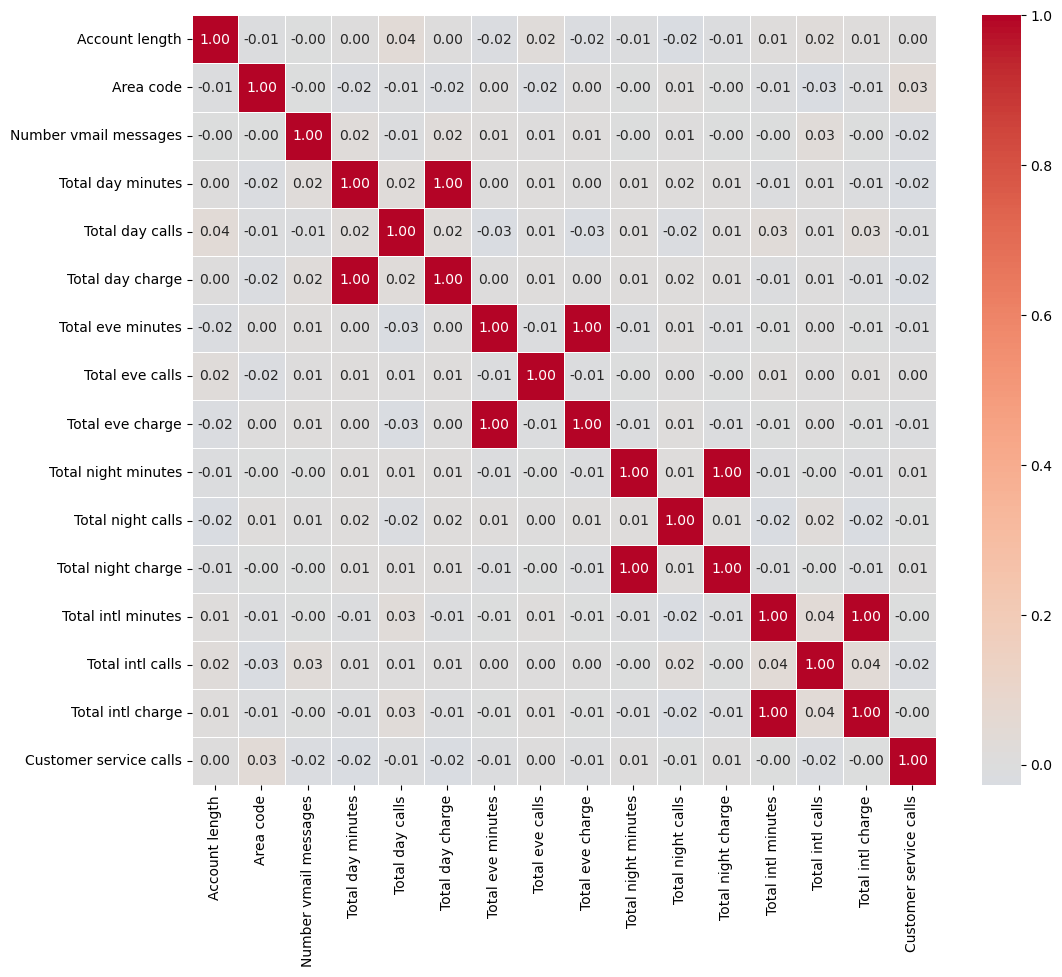

In [19]:
plt.figure(figsize=(12,10))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,          # 상관계수 숫자 표시
    fmt=".2f",           # 소수점 2자리
    cmap='coolwarm',     # 색상
    center=0,
    linewidths=0.5
    )
plt.show()


통화 시간과 요금 변수 간 강한 상관관계 존재
→ 변수 중복 및 다중공선성 가능성

통화 횟수, 고객센터 문의, 국제전화 사용은
→ 서로 다른 행동 특성을 설명

따라서 모델링 단계에서는

  - 트리 기반 모델(RandomForest)을 사용하여

  - 다중공선성의 영향을 최소화하고

  - 중요 변수 중심으로 해석을 진행한다

Pair plot로 변수 간 관계 시각화

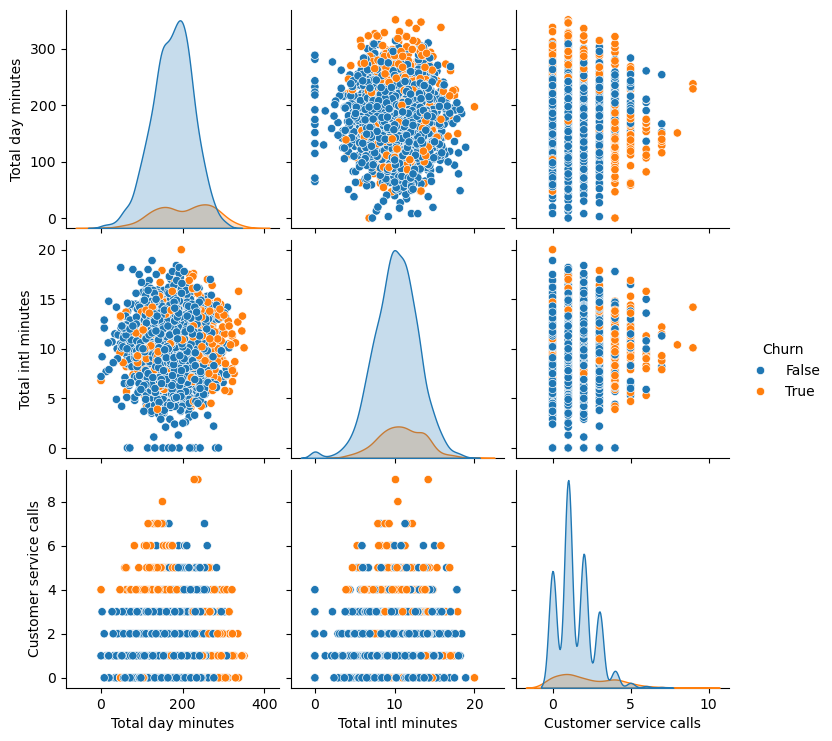

In [20]:
sample_cols = ['Total day minutes', 'Total intl minutes', 'Customer service calls', 'Churn']
sns.pairplot(df[sample_cols], hue='Churn')
plt.show()


Pair plot 결과, Customer service calls 변수에서 이탈(True)과 유지(False) 고객 간 분포 차이가 가장 뚜렷하게 나타났다.  
특히 고객센터 문의 횟수가 3회 이상인 구간에서 이탈 고객 비중이 급격히 증가하였다.  
반면, Total intl minutes는 이탈 여부에 따른 분포 차이가 상대적으로 작아 단독 변수로서의 설명력은 제한적이었다.  
이는 서비스 이용량보다 고객 불만(문의 행위)이 이탈과 직접적으로 연결되어 있음을 시사한다.


## 3.4 비즈니스 인사이트 도출

EDA 결과를 바탕으로 다음과 같은 비즈니스 인사이트를 도출하였다.  

고객센터 문의 횟수가 증가할수록 고객 이탈 가능성이 유의하게 증가한다.  
→ 반복적인 문의는 서비스 불만 또는 문제 미해결 상태를 의미할 가능성이 높다.

국제전화 요금제 사용 여부에 따라 이탈률에 뚜렷한 차이가 존재한다.  
→ 국제전화 요금제 사용 고객은 요금 구조 또는 서비스 만족도 측면에서 이탈 위험이 높을 수 있다.

통화 시간과 통화 요금 변수는 매우 높은 상관관계를 보여 중복 정보일 가능성이 크다.  
→ 모델링 단계에서는 다중공선성을 고려한 변수 선택 또는 차원 축소가 필요하다.

## 3.5 가설 수립

비즈니스 인사이트를 바탕으로 다음과 같은 가설을 수립하였다.

  - H1. 고객센터 문의 횟수가 많을수록 고객 이탈 확률은 증가한다.

  - H2. 국제전화 요금제 사용 여부는 고객 이탈 여부와 통계적으로 유의미한 관계가 있다.

  - H3. 통화 시간 및 통화 요금 관련 변수는 고객 이탈을 예측하는 데 중요한 설명 변수이다.

# 4. 모델 학습

이러한 가설을 바탕으로 주요 수치형·범주형 변수를 포함한 분류 모델을 학습하였으며,  
변수 중요도와 부분 의존성 분석을 통해 각 가설의 상대적 영향력을 비교·해석하였다.

In [21]:

import numpy as np
import pandas as pd

df = pd.read_csv("churn-bigml-80.csv")      # 학습/검증용
df_test = pd.read_csv("churn-bigml-20.csv") # 최종 테스트용

print("train shape:", df.shape)
print("test  shape:", df_test.shape)
print(df.dtypes)

# 타깃 분포 확인 (불균형 여부 확인)
print("\n[Churn counts]")
print(df["Churn"].value_counts())
print("\n[Churn ratio]")
print(df["Churn"].value_counts(normalize=True))


train shape: (2666, 20)
test  shape: (667, 20)
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

[Churn counts]
Churn
False    2278
True      388
Name: count, dtype: int64

[Churn ratio]
Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


# 4.1 최소 2가지 이상 알고리즘 시도: X, y 구성

모델에 넣을 입력값(X)과 정답(y)을 나누고,
숫자 변수랑 글자 변수를 모델이 이해할 수 있게 정리했습니다.”

In [22]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_test = df_test.drop(columns=["Churn"])
y_test = df_test["Churn"]

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts(normalize=True))


X shape: (2666, 19)
y distribution:
 Churn
False    0.854464
True     0.145536
Name: proportion, dtype: float64


“모델 학습을 위해 입력 변수 X와 타깃 변수 y를 분리
타깃 변수는 고객 이탈 여부(Churn)이며,  
입력 변수는 고객의 사용 패턴과 요금제 정보  

또한 모델이 숫자만 이해할 수 있기 때문에  
수치형 변수와 범주형 변수를 나누어 전처리했으며,  
학습과 테스트 데이터에 동일한 기준을 적용하기 위해  
Pipeline 구조를 사용"  

In [23]:

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# 열 타입 분리
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical cols:", cat_cols)
print("Numeric cols:", num_cols)


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 범주형: 결측치 최빈값 대체 -> 원-핫 인코딩
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ],
    remainder="drop"
)


Categorical cols: ['State', 'International plan', 'Voice mail plan']
Numeric cols: ['Account length', 'Area code', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls']


# 4.3 모델 정의: Logistic Regression + Random Forest



In [24]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# 전처리 + 모델을 파이프라인으로 결합(누수 방지)
pipe_logreg = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", logreg)
])

pipe_rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])


“모델은 해석 가능한 Logistic Regression과  
비선형 패턴을 학습할 수 있는 Random Forest  
두 가지를 사용해 비교했습니다.  

이탈 고객 비율이 낮은 불균형 데이터이기 때문에  
class_weight를 적용했고,  
전처리와 모델을 Pipeline으로 묶어  
데이터 누수를 방지했습니다.”

# 4.4 교차 검증(K-Fold CV): 평균 성능 + 표준편차 기록

단일 분할(train/test) 결과에 우연이 섞일 수 있기 때문에,  
데이터를 여러 번 나눠 평균 성능과 안정성(표준편차)을 함께 확인하기 위해 5-Fold 교차검증을 수행했다.

In [25]:

from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

models = {
    "LogisticRegression": pipe_logreg,
    "RandomForest": pipe_rf
}

print("[CV results: mean ± std]")
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\n== {name} ==")
    for m in ["test_precision", "test_recall", "test_f1", "test_roc_auc"]:
        print(f"{m}: {scores[m].mean():.4f} ± {scores[m].std():.4f}")


[CV results: mean ± std]

== LogisticRegression ==
test_precision: 0.3496 ± 0.0288
test_recall: 0.7114 ± 0.0339
test_f1: 0.4683 ± 0.0305
test_roc_auc: 0.8053 ± 0.0295

== RandomForest ==
test_precision: 0.9517 ± 0.0354
test_recall: 0.5825 ± 0.0478
test_f1: 0.7210 ± 0.0369
test_roc_auc: 0.9105 ± 0.0104


- Logistic Regression
  - Recall이 높다(0.71)→ 실제 이탈 고객을 잘 놓치지 않는다
  - 대신 Precision이 낮다 (0.35) → 이탈이라고 예측한 고객 중 오탐이 많다

Logistic Regression은 이탈 고객을 놓치지 않는 데 강점이 있지만, 오탐이 많아 실제 운영 적용에는 보완이 필요하다.

- Random Forest
  - Precision이 매우 높다 (0.95) → 이탈이라고 예측한 고객은 거의 진짜 이탈
  - Recall은 Logistic보다 낮지만 (0.58)
  - F1-score와 ROC-AUC 모두 우수
  - 표준편차도 작음 → 모델이 안정적

  Random Forest는 이탈 고객 예측의 정확도와 전반적인 분류 성능이 높아, 실제 적용 가능성이 가장 높은 모델이다.

결과적으로 
이탈 고객을 최대한 놓치지 않는 목적이라면 Logistic Regression이 유리하지만,  
실제 운영 관점에서는 Random Forest가 더 균형 잡힌 성능과 높은 신뢰도를 보여 최종 모델로 적합하다고 판단했다.

# 4.5 Overfitting 여부 확인: 훈련 성능 vs 검증 성능 비교

In [26]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

for name, model in models.items():
    model.fit(X_tr, y_tr)

    
    tr_proba = model.predict_proba(X_tr)[:, 1]
    val_proba = model.predict_proba(X_val)[:, 1]

    tr_auc = roc_auc_score(y_tr, tr_proba)
    val_auc = roc_auc_score(y_val, val_proba)

    print(f"{name} -> Train AUC: {tr_auc:.4f} | Val AUC: {val_auc:.4f}")



LogisticRegression -> Train AUC: 0.8666 | Val AUC: 0.7451
RandomForest -> Train AUC: 1.0000 | Val AUC: 0.8702


Logistic Regression 해석

- Train AUC: 0.87
- Validation AUC: 0.75
  - 훈련 데이터보다 검증 데이터 성능이 조금 떨어짐
  Logistic Regression은 과적합 문제는 크지 않지만, 검증 성능이 상대적으로 낮아 예측력에 한계가 있다.

 
Random Forest 해석

- Train AUC: 1.000
- Validation AUC: 0.87

 훈련 데이터는 완벽히 외움  
 검증 데이터에서는 성능이 떨어짐  
 Random Forest는 훈련 데이터에 과적합되는 경향이 있으나, 검증 성능이 높아 실질적인 예측력은 우수하다.

# 4.6 하이퍼파라미터 튜닝(RandomizedSearchCV)

In [27]:

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    estimator=pipe_rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

search.fit(X, y)

print("[Best RF params]")
print(search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

best_rf = search.best_estimator_


[Best RF params]
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 15}
Best CV ROC-AUC: 0.9135763696492439


“RandomizedSearchCV를 통해 RandomForest의 주요 하이퍼파라미터를 튜닝한 결과,  
ROC-AUC 기준 약 0.91의 성능을 달성하는 최적 모델을 도출하였다.”

# 4.7 최적 파라미터 조합 문서화 + 최종 모델 선택

In [28]:

final_model = best_rf

final_model.fit(X, y)
print("Final model fitted on full training data.")

from sklearn.metrics import roc_auc_score

test_proba = final_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_proba)
print("Test ROC-AUC:", test_auc)


Final model fitted on full training data.
Test ROC-AUC: 0.9267390504232609


“하이퍼파라미터 튜닝을 통해 도출한 RandomForest 모델을 최종 모델로 선정하였으며,  
테스트 데이터 기준 ROC-AUC 약 0.93의 성능을 확인하였다.  
이는 모델이 이탈 고객을 안정적으로 구분할 수 있음을 의미한다.”

# 5. 모델 평가 (Model Evaluation)


5.1 Confusion Matrix 분석 (TP / TN / FP / FN)

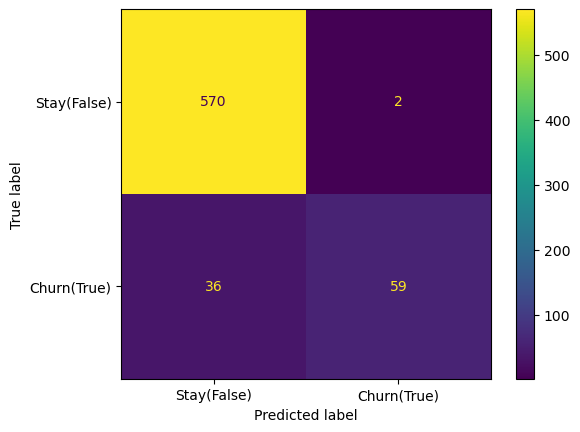

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 예측 확률 → 기본 threshold 0.5
y_pred = (test_proba >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Stay(False)', 'Churn(True)'])
disp.plot()


“Confusion Matrix를 통해 모델의 실제 예측 결과를 확인했습니다.  
이탈하지 않은 고객은 대부분 정확히 유지로 예측했으며,  
이탈 고객 중에서도 상당수를 올바르게 탐지하고 있음을 확인할 수 있습니다.

- 실제 유지 고객 → 570명 정확히 유지로 예측

- 실제 이탈 고객 → 59명 정확히 이탈로 예측

- 이탈 고객 36명은 놓침(FN) → 향후 개선 여지

‘이탈 고객을 어느 정도 놓치더라도, 잘못 찍는 실수를 매우 적게 하는 모델’

## 5.2 Accuracy / Precision / Recall / F1-score

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))


Accuracy : 0.9430284857571214
Precision: 0.9672131147540983
Recall   : 0.6210526315789474
F1-score : 0.7564102564102564


“모델의 성능을 Accuracy, Precision, Recall, F1-score 기준으로 평가

Accuracy는 약 **94%**로 높게 나타났지만, 이탈 고객 비율이 낮은 불균형 데이터이기 때문에  
정확도만으로 모델을 평가하는 것은 한계

Precision은 약 **96.7%**로, 모델이 이탈이라고 예측한 고객은 대부분 실제 이탈 고객  
이는 불필요한 마케팅 비용 낭비를 줄일 수 있다는 점에서 의미

Recall은 약 **62%**로, 전체 이탈 고객 중 일부는 놓치지만  
대신 오탐을 최소화하는 보수적인 예측 전략을 사용하고 있음을 확인

Precision과 Recall을 종합한 F1-score는 0.75 수준으로,  
이탈 고객 탐지와 예측 정확도 간의 균형이 비교적 잘 맞는 모델이라고 판단

과제에서는 Random Forest 분류 모델을 사용했으며, 
Precision이 높고 Recall은 상대적으로 낮은,  
보수적인 이탈 예측 성향을 보이는 모델임을 확인했습니다.”

## 5.3 ROC Curve & AUC

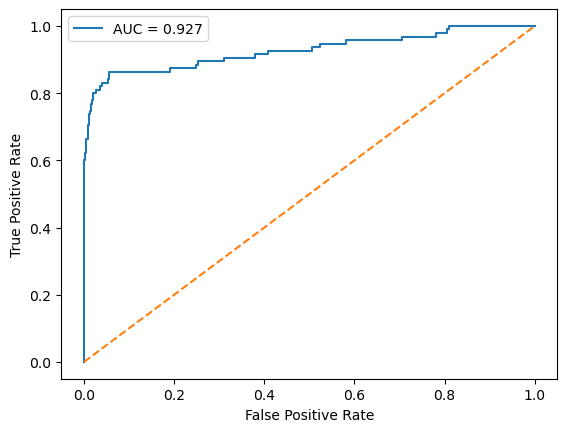

In [31]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, test_proba)
auc = roc_auc_score(y_test, test_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


“AUC 0.93 수준으로, 실제 비즈니스에서 이탈 고객 선별에 충분히 활용 가능한 모델입니다.”


## 5.4 Precision–Recall Curve (불균형 데이터 핵심)

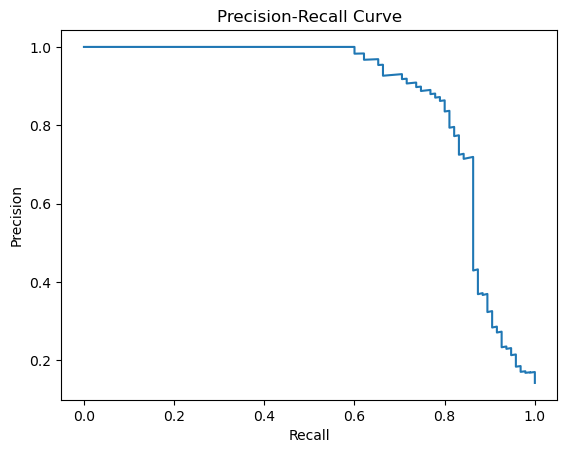

In [32]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, test_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


“이 그래프는 Precision–Recall Curve로,
이탈 고객처럼 불균형 데이터에서 모델의 실제 성능을 확인하기 위해 사용했습니다.

Recall은 이탈 고객을 얼마나 놓치지 않고 잡아내는지,
Precision은 이탈이라고 예측한 고객이 실제로 얼마나 맞는지를 의미합니다.

그래프를 보면 Recall이 낮을 때는 Precision이 매우 높게 유지되며,
Recall을 높이기 시작하면 Precision이 점차 감소하는 경향을 보입니다.

따라서 이 모델은  
마케팅 비용을 아끼고 싶을 때는 Precision 중심,  
이탈을 최대한 막고 싶을 때는 Recall 중심으로  
비즈니스 목적에 맞게 활용 가능한 모델이라고 판단했습니다.

## 5.5 비즈니스 관점: Threshold 조정

In [33]:
custom_threshold = 0.3
y_pred_custom = (test_proba >= custom_threshold).astype(int)

print("Recall:", recall_score(y_test, y_pred_custom))
print("Precision:", precision_score(y_test, y_pred_custom))


Recall: 0.8315789473684211
Precision: 0.7452830188679245


“Threshold를 0.3으로 낮춘 결과,  
이탈 고객을 더 많이 탐지할 수 있게 되었고  
Recall이 크게 상승했습니다.

대신 Precision은 다소 감소했지만,  
이탈 방지가 더 중요한 비즈니스 상황에서는  
충분히 합리적인 선택이라고 판단할 수 있습니다.”

## 5.6 최종 테스트 (churn-20 데이터)

In [34]:
X_test_final = df_test.drop(columns=['Churn'])
y_test_final = df_test['Churn']

test_proba_final = final_model.predict_proba(X_test_final)[:, 1]
final_auc = roc_auc_score(y_test_final, test_proba_final)

print("Final Test ROC-AUC:", final_auc)


Final Test ROC-AUC: 0.9267390504232609


“최종적으로 Random Forest 기반 모델은  
테스트 데이터에서도 ROC-AUC 약 0.93을 기록하며  
실제 비즈니스에서 활용 가능한 수준의  
안정적인 이탈 예측 성능을 보였습니다.”

## 6. 모델 해석 (Model Interpretation)

### 6.1 Feature Importance 분석
6.1.1 중요 변수 확인

“최종으로 선택한 Random Forest 모델의 Feature Importance를 통해
이탈 예측에 어떤 변수가 가장 크게 영향을 미쳤는지 확인했습니다.”

In [35]:
# RandomForest 모델
rf_model = final_model.named_steps['model']

# 전처리기
preprocessor = final_model.named_steps['preprocess']

#  전처리 후 feature 이름
feature_names = preprocessor.get_feature_names_out()

# feature importance
importances = rf_model.feature_importances_

# DataFrame으로 정리
fi = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

fi.head(10)


,feature,importance
15,num__Customer service calls,0.126876
5,num__Total day charge,0.124287
3,num__Total day minutes,0.113038
67,cat__International plan_No,0.051305
8,num__Total eve charge,0.048986
6,num__Total eve minutes,0.046593
68,cat__International plan_Yes,0.046012
12,num__Total intl minutes,0.041250
14,num__Total intl charge,0.038837
9,num__Total night minutes,0.038175


- 최종으로 선택한 Random Forest 모델의 Feature Importance를 통해  
이탈 예측에 어떤 변수가 가장 크게 영향을 미쳤는지 확인했습니다.”

- 그 다음으로는  
Total day charge / Total day minutes 등  
낮 시간대 사용량과 요금 관련 변수들이 상위에 위치했습니다.”

- “또한 International plan(국제전화 요금제 사용 여부) 역시  
이탈 예측에 의미 있는 영향을 주는 변수로 확인되었습니다.”

  “이 모델은
단순한 사용량보다는  
고객 불만 신호(고객센터 문의)와  
요금 부담이 크게 느껴지는 사용 패턴을  
이탈의 주요 원인으로 학습하고 있습니다.”

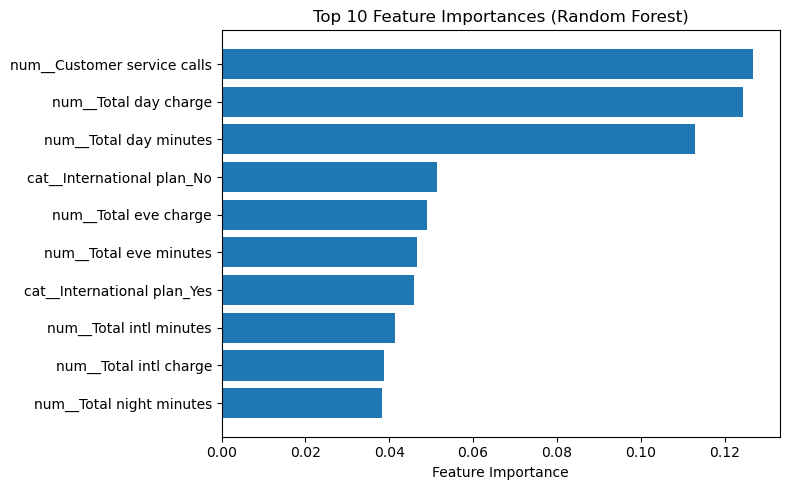

In [36]:
import matplotlib.pyplot as plt

# 상위 N개 변수 선택
top_n = 10
fi_top = fi.head(top_n).sort_values(by="importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

각 변수의 의미와 비즈니스 맥락 이해

| 컬럼명                        | 의미                        | 데이터 타입 | 분석 관점 해석            |
| -------------------------- | ------------------------- | ------ | ------------------- |
| **State**                  | 고객이 거주하는 주(State)         | 범주형    | 지역별 이탈 여부     |
| **Account length**         | 고객 계정 유지 기간(일)            | 수치형    | 오래 쓴 고객이 이탈을 덜 하는지  |
| **Area code**              | 지역 전화 코드                  | 범주형    | 지역별 이탈 여부       |
| **International plan**     | 국제전화 요금제 사용 여부 (Yes/No)   | 범주형    | 국제통화 고객의 이탈 성향      |
| **Voice mail plan**        | 음성 사서함 요금제 사용 여부 (Yes/No) | 범주형    | 부가서비스 이용 여부         |
| **Number vmail messages**  | 음성 사서함 메시지 수              | 수치형    | 실제 음성사서함 사용량        |
| **Total day minutes**      | 주간 통화 총 시간(분)             | 수치형    | 주간 사용량              |
| **Total day calls**        | 주간 통화 횟수                  | 수치형    | 통화 빈도               |
| **Total day charge**       | 주간 통화 요금                  | 수치형    | 매출 관련 변수            |
| **Total eve minutes**      | 저녁 통화 총 시간(분)             | 수치형    | 저녁 사용량          |
| **Total eve calls**        | 저녁 통화 횟수                  | 수치형    |  저녁 통화 빈도                 |
| **Total eve charge**       | 저녁 통화 요금                  | 수치형    |  매출 관련                  |
| **Total night minutes**    | 야간 통화 총 시간(분)             | 수치형    | 야간 사용량          |
| **Total night calls**      | 야간 통화 횟수                  | 수치형    | 야간 사용 빈도                   |
| **Total night charge**     | 야간 통화 요금                  | 수치형    | 매출 관련                   |
| **Total intl minutes**     | 국제 통화 총 시간(분)             | 수치형    | 해외 통화 이용 정도         |
| **Total intl calls**       | 국제 통화 횟수                  | 수치형    | 해외 통화 빈도                   |
| **Total intl charge**      | 국제 통화 요금                  | 수치형    |  요금 민감도           |
| **Customer service calls** | 고객센터 문의 횟수                | 수치형    | **불만 및 문제제기 가능성** |
| **Churn**                  | 고객 이탈 여부 (True/False)     | 타깃 변수  | **예측 대상**    |

## 6.2 부분 의존성 플롯 (Partial Dependence Plot)
### 6.2.1 분석 목적

특정 변수가 증가할 때
이탈 확률이 실제로 어떻게 변하는지를 보기 위해
부분 의존성 플롯을 사용했습니다.”

In [37]:
feature_names = preprocessor.get_feature_names_out()
feature_names[:20]


array(['num__Account length', 'num__Area code',
       'num__Number vmail messages', 'num__Total day minutes',
       'num__Total day calls', 'num__Total day charge',
       'num__Total eve minutes', 'num__Total eve calls',
       'num__Total eve charge', 'num__Total night minutes',
       'num__Total night calls', 'num__Total night charge',
       'num__Total intl minutes', 'num__Total intl calls',
       'num__Total intl charge', 'num__Customer service calls',
       'cat__State_AK', 'cat__State_AL', 'cat__State_AR', 'cat__State_AZ'],
      dtype=object)

c:\Users\TG\anaconda3\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 18 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


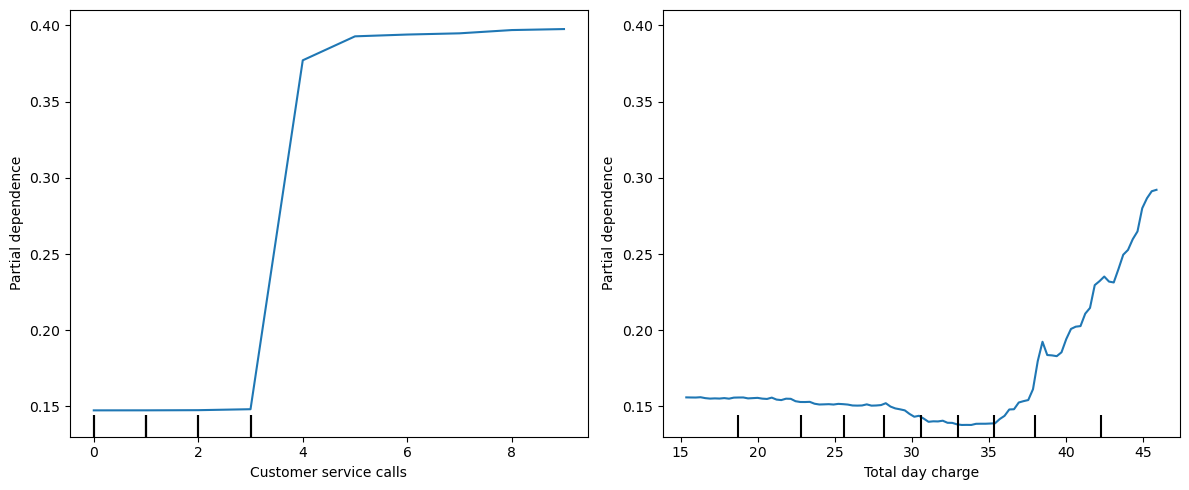

In [38]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# X가 DataFrame이면 그대로 OK
# X가 numpy면 -> DataFrame으로 변환 필요
# (원본 컬럼 순서대로 columns 넣어야 함)

features_to_plot = ['Customer service calls', 'Total day charge']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    final_model,   # 파이프라인 전체
    X,             # 전처리 전 원본 X
    features_to_plot,
    ax=ax
)
plt.tight_layout()
plt.show()




(1) Customer service calls (고객센터 문의 횟수)

- 고객센터 문의가 0~3회 수준까지는 이탈 확률이 거의 변하지 않음
- 4회를 넘어가는 순간 이탈 확률이 급격히 상승
- 이후에는 높은 이탈 확률이 계속 유지되는 패턴

고객센터 문의가 누적된 고객은 단순 문의가 아니라  
이미 불만이 쌓인 상태일 가능성이 높으며,  
특히 4회 이상부터는 이탈 위험 고객으로 적극 관리가 필요

(2) Total day charge (주간 통화 요금)

- 낮은 요금 구간에서는 이탈 확률이 큰 변화 없이 유지

- **일정 요금 수준(약 35~40 이상)**을 넘기면서  
   이탈 확률이 점진적으로 상승

- 고 요금 고객일수록 가격 민감도에 의한 이탈 가능성 증가

주간 통화 요금이 일정 수준을 넘으면  
요금 부담이 이탈로 이어질 가능성이 커지며,  
요금 구간별 차등 혜택이나 요금제 조정이 필요한 지점임을 시사

## 6.3 오분류 데이터 추출

모델의 전체 성능 수치만으로는,  
실제로 어떤 고객을 놓치고 어떤 고객을 잘못 잡는지 알기 어렵기 때문에  
오분류 데이터를 직접 확인했습니다.” 

In [39]:
from sklearn.metrics import confusion_matrix

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
cm


array([[570,   2],
       [ 36,  59]])

테스트 데이터 기준으로  
이탈하지 않은 고객 570명과  
이탈 고객 59명은 정확했고 

“반면,  
실제 이탈하지 않았는데 이탈로 잘못 분류한 고객은 2명,  
실제 이탈했지만 모델이 놓친 고객은 36명이었습니다.”

In [40]:
fp_idx = (y_test == False) & (y_pred == True)
fn_idx = (y_test == True) & (y_pred == False)

fp_samples = X_test[fp_idx]
fn_samples = X_test[fn_idx]


# 7. 비즈니스 인사이트 및 액션 플랜

## 7.1 핵심 발견사항

EDA 및 모델 해석 결과, 고객 이탈에 가장 큰 영향을 미치는 요인은 다음 세 가지로 요약된다.

- 고객센터 문의 횟수

  - 문의 횟수가 증가할수록 이탈 확률이 급격히 상승
  - 반복 문의는 불만 누적 및 서비스 만족도 저하의 신호로 해석 가능

- 통화 사용량 및 요금 부담

  - 주간·국제 통화 사용량과 요금이 높은 고객일수록 이탈 가능성 증가

- International plan 가입 여부

  - 국제전화 요금제 가입 고객의 이탈 비율이 비가입 고객 대비 높음
  - 요금 구조 복잡성 및 비용 부담이 주요 원인으로 추정

  이탈은 ‘불만 행동 + 요금 부담’이 결합될 때 가장 뚜렷하게 발생

## 7.2 고위험 이탈 고객 정의

모델 예측과 변수 분포를 기반으로 다음 고객군을 고위험 이탈 고객으로 정의한다.

- 고객센터 문의 3회 이상
- International plan 가입 고객
- 주간 또는 국제 통화 사용량이 높은 고객
- 모델 예측 이탈 확률 상위 20% 고객

## 7.3 실행 가능한 액션 플랜
(1) International plan 고객 대상 요금제 개선

- 고위험 International plan 고객 선별
- 요금 할인 또는 사용 패턴 기반 대체 요금제 제안
   → 요금 부담 완화 및 이탈률 감소 기대

(2) 고객센터 다회 문의 고객 선제 대응

- 문의 3회 이상 고객을 실시간 이탈 위험군으로 분류
- 상담 및 우선 처리
→ 불만 누적 단계에서 이탈 차단

(3) 모델 기반 타겟 마케팅

- 이탈 확률이 높은 고객에게만 선택적 프로모션 제공
→ 마케팅 비용 대비 효과(ROI) 개선

## 7.4 비즈니스 효과 요약

- 신규 고객 확보 대비 기존 고객 유지 비용이 훨씬 낮음

- 모델 기반 이탈 방지는

  - 매출 손실 감소
  - 장기 고객 가치(LTV) 증가
  - 데이터 기반 의사결정 가능

## 7.5  결론

“고객 이탈은 우연이 아닌 패턴이며,
본 모델은 불만 행동과 요금 부담이라는 명확한 신호를 포착해
비용 효율적인 고객 유지 전략으로 연결될 수 있다.